In [2]:
#####################################################
# Imports and Simulation IO
#####################################################

from MDToolkit.IO.read_file import lammps_data_file_to_structured_system, lammps_dump_file_to_simulation
from MDToolkit.data.objects import Simulation, StructuredSystem
from MDToolkit.data.misc_objects import BoxVolume, CylinderVolume, get_max_box_volume_from_simulation
from MDToolkit.analysis.density import axial_density, axial_density_time_averaged, radial_density, radial_density_time_averaged

cyl = CylinderVolume([-24.5, 0, 0], [24.5, 0, 0], 10.5)

file_path = "/media/jrjoseph/Elements/projects/training/cnt_water_ls6/density_calculation/cnt1616_water_nvt_prod.out"

type_dict = {
    1 : "O",
    2 : "C",
    3 : "H"
}

simulation = lammps_dump_file_to_simulation(file_path, type_dict)

# volumes = [get_max_box_volume_from_simulation(simulation)]

# volumes = [BoxVolume([-104, -27.69, -27.15], [-53, 27.69, 27.15]), BoxVolume([53, -27.69, -27.15], [104, 27.69, 27.15])]


Processing frames:   0%|          | 0/1501 [00:00<?, ?frame(s)/s]

In [12]:
#####################################################
# Plotting Functions
#####################################################

import numpy as np
import matplotlib.pyplot as plt


def plot_axial_density(
    density_data,
    show_density_std=True,
    show_avg_density_band=True,
    figsize=(8, 5),
    ax=None
):
    """
    Plot time-averaged mass density profile.

    Parameters
    ----------
    density_data : dict
        Output from axial_density_time_averaged().
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    x = density_data["bin_centers"]

    rho_mean = density_data["density_mean"]
    rho_std = density_data["density_std"]

    avg_rho = density_data["average_density_mean"]
    avg_rho_std = density_data["average_density_std"]

    ax.plot(
        x,
        rho_mean,
        lw=2,
        label="Density"
    )

    if show_density_std:
        ax.fill_between(
            x,
            rho_mean - rho_std,
            rho_mean + rho_std,
            alpha=0.25,
            label="Density Std Dev"
        )

    ax.axhline(
        avg_rho,
        ls="--",
        lw=2,
        label=fr"Average Density = {avg_rho:.3f} g/cm$^3$"
    )

    if show_avg_density_band:
        ax.axhspan(
            avg_rho - avg_rho_std,
            avg_rho + avg_rho_std,
            alpha=0.15,
            label=fr"Average Density Std Dev = {avg_rho_std:.3f}"
        )

    ax.set_xlabel("Position")
    ax.set_ylabel(r"Density (g cm$^{-3}$)")

    ax.margins(x=0.02)

    ax.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True
    )

    ax.minorticks_on()

    ax.legend(frameon=False)

    plt.tight_layout()

    return ax


def plot_axial_number_density(
    density_data,
    show_std=True,
    figsize=(8, 5),
    ax=None
):
    """
    Plot total number density profile.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    x = density_data["bin_centers"]

    y = density_data["number_density_mean"]
    y_std = density_data["number_density_std"]

    ax.plot(
        x,
        y,
        lw=2,
        label="Number Density"
    )

    if show_std:
        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            alpha=0.25
        )

    ax.set_xlabel("Position")
    ax.set_ylabel("Normalized Number Density")

    ax.margins(x=0.02)

    ax.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True
    )

    ax.minorticks_on()

    ax.legend(frameon=False)

    plt.tight_layout()

    return ax


def plot_axial_elemental_number_density(
    density_data,
    elements=None,
    show_std=True,
    figsize=(8, 5),
    ax=None
):
    """
    Plot elemental number density profiles.

    Parameters
    ----------
    elements : list[str] or None
        Elements to plot. If None, all elements are plotted.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    x = density_data["bin_centers"]

    mean_data = density_data["elemental_number_density_mean"]
    std_data = density_data["elemental_number_density_std"]

    if elements is None:
        elements = sorted(mean_data.keys())

    for element in elements:

        y = mean_data[element]
        y_std = std_data[element]

        ax.plot(
            x,
            y,
            lw=2,
            label=element
        )

        if show_std:
            ax.fill_between(
                x,
                y - y_std,
                y + y_std,
                alpha=0.20
            )

    ax.set_xlabel("Position")
    ax.set_ylabel("Normalized Elemental Number Density")

    ax.margins(x=0.02)

    ax.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True
    )

    ax.minorticks_on()

    ax.legend(
        title="Element",
        frameon=False,
        ncol=min(4, len(elements))
    )

    plt.tight_layout()

    return ax

def plot_radial_density(
    density_data,
    show_density_std=True,
    show_avg_density_band=True,
    figsize=(8, 5),
    ax=None
):
    """
    Plot time-averaged radial mass density profile.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    r = density_data["bin_centers"]

    rho_mean = density_data["density_mean"]
    rho_std = density_data["density_std"]

    avg_rho = density_data["average_density_mean"]
    avg_rho_std = density_data["average_density_std"]

    ax.plot(
        r,
        rho_mean,
        lw=2,
        label="Density"
    )

    if show_density_std:
        ax.fill_between(
            r,
            rho_mean - rho_std,
            rho_mean + rho_std,
            alpha=0.25,
            label="Density Std Dev"
        )

    ax.axhline(
        avg_rho,
        ls="--",
        lw=2,
        label=fr"Average Density = {avg_rho:.3f} g/cm$^3$"
    )

    if show_avg_density_band:
        ax.axhspan(
            avg_rho - avg_rho_std,
            avg_rho + avg_rho_std,
            alpha=0.15,
            label=fr"Average Density Std Dev = {avg_rho_std:.3f}"
        )

    ax.set_xlabel(r"Radius ($\AA$)")
    ax.set_ylabel(r"Density (g cm$^{-3}$)")

    ax.margins(x=0.02)

    ax.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True
    )

    ax.minorticks_on()

    ax.legend(frameon=False)

    plt.tight_layout()

    return ax

def plot_radial_elemental_number_density(
    density_data,
    elements=None,
    show_std=True,
    figsize=(8, 5),
    ax=None
):
    """
    Plot radial elemental number density profiles.

    Parameters
    ----------
    elements : list[str] or None
        Elements to plot. If None, all are plotted.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    r = density_data["bin_centers"]

    mean_data = density_data["elemental_number_density_mean"]
    std_data = density_data["elemental_number_density_std"]

    if elements is None:
        elements = sorted(mean_data.keys())

    for element in elements:

        y = mean_data[element]
        y_std = std_data[element]

        ax.plot(
            r,
            y,
            lw=2,
            label=element
        )

        if show_std:
            ax.fill_between(
                r,
                y - y_std,
                y + y_std,
                alpha=0.20
            )

    ax.set_xlabel(r"Radius ($\AA$)")
    ax.set_ylabel("Normalized Elemental Number Density")

    ax.margins(x=0.02)

    ax.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True
    )

    ax.minorticks_on()

    ax.legend(
        title="Element",
        frameon=False,
        ncol=min(4, len(elements))
    )

    plt.tight_layout()

    return ax

def plot_radial_number_density(
    density_data,
    show_std=True,
    figsize=(8, 5),
    ax=None
):
    """
    Plot radial number density profile.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    r = density_data["bin_centers"]

    y = density_data["number_density_mean"]
    y_std = density_data["number_density_std"]

    ax.plot(
        r,
        y,
        lw=2
    )

    if show_std:
        ax.fill_between(
            r,
            y - y_std,
            y + y_std,
            alpha=0.20
        )

    ax.set_xlabel(r"Radius ($\AA$)")
    ax.set_ylabel("Normalized Number Density")

    ax.margins(x=0.02)

    ax.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True
    )

    ax.minorticks_on()

    plt.tight_layout()

    return ax


In [ ]:
cyl = CylinderVolume([-24.5, 0, 0], [24.5, 0, 0], 8.0)
volumes = [BoxVolume([-104, -27.69, -27.15], [-53, 27.69, 27.15]), cyl, BoxVolume([53, -27.69, -27.15], [104, 27.69, 27.15])]

In [ ]:
avg_density = axial_density_time_averaged(
    simulation,
    volumes,
    bins=250,
    axis="x",
)

In [ ]:
plot_axial_density(avg_density)
plt.show()
plot_axial_number_density(avg_density)
plt.show()
plot_axial_elemental_number_density(avg_density)
plt.show()

In [15]:
rd = radial_density_time_averaged(simulation, cyl, bins = 150)

Performing density calculations:: 100%|██████████| 1501/1501 [00:40<00:00, 37.13frame(s)/s]


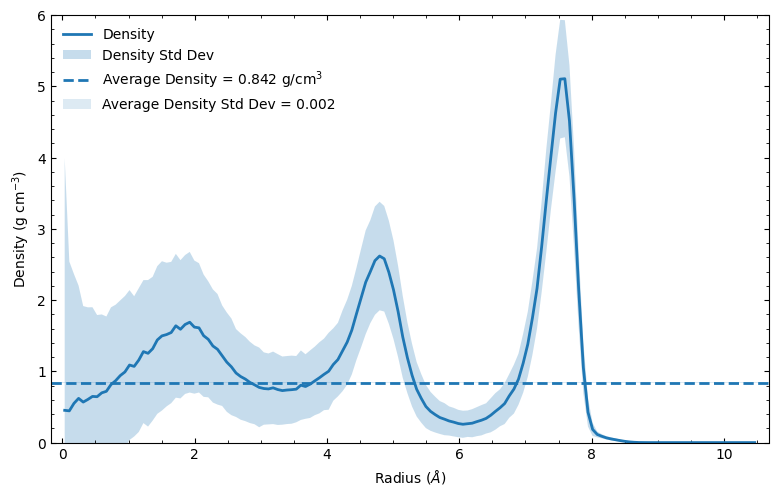

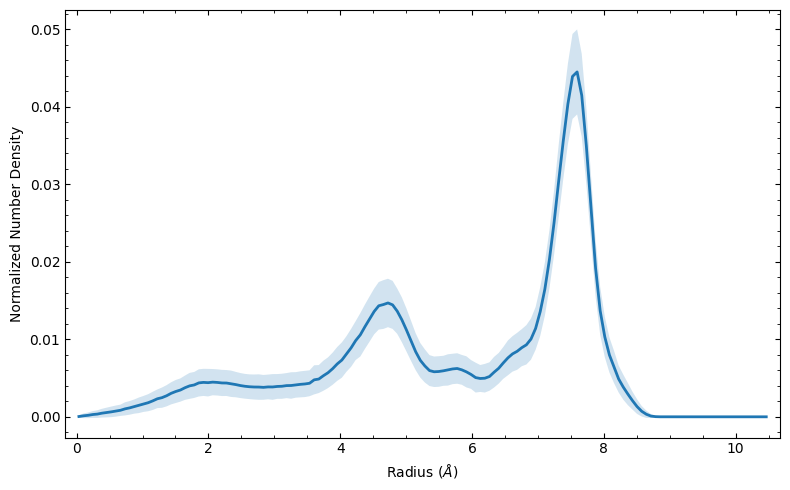

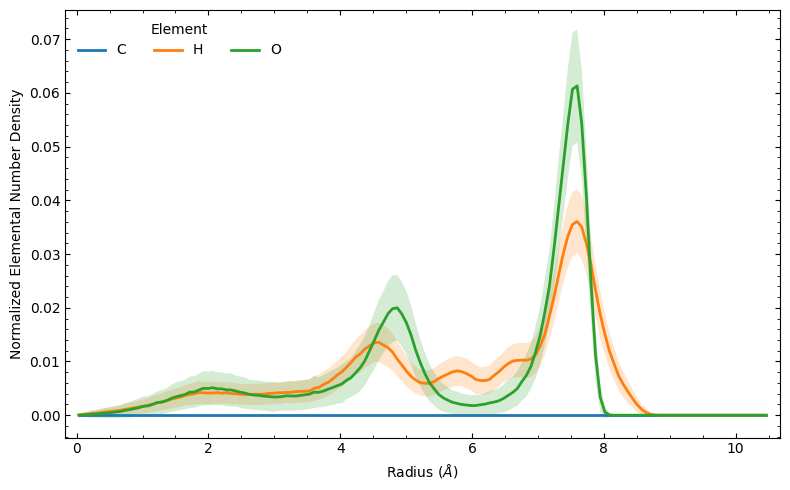

In [ ]:
plot_radial_density(rd, show_density_std=False)
plt.ylim(0, 6)
plt.show()

plot_radial_number_density(rd)
plt.show()

plot_radial_elemental_number_density(rd)
plt.show()